# Cobertura thoracic + lumbar para entrenamiento

Este notebook redefine el problema de segmentacion multiclase segun la nueva decision del experto: **se excluyen las vertebras cervicales** y el objetivo anatomico queda limitado a:

- `T1` a `T12`
- `L1` a `L5`

La meta de este analisis es dejar una base clara y util para el siguiente paso del proyecto: crear notebooks de entrenamiento enfocados solo en vertebras toracicas y lumbares.


## Que cambia respecto a los notebooks anteriores

En este notebook:

- las cervicales (`C3` a `C7`) dejan de formar parte del target,
- si aparecen en una mascara, se registran como **vertebras excluidas del target** y no como error,
- la auditoria de continuidad interna solo se hace sobre las regiones `thoracic` y `lumbar`,
- y el `manifest` final se genera especificamente para entrenamiento thoracolumbar.

Esto es importante porque evita que el pipeline trate la presencia o ausencia cervical como un problema de anotacion cuando en realidad ya no nos interesa modelarla.


In [1]:
from __future__ import annotations

import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

plt.style.use('ggplot')
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 200)


In [2]:
def _resolve_maia_project_root(marker: Path) -> Path:
    """Raiz del repo (carpeta que contiene marker). Local, subcarpetas, Colab+Drive."""
    env = os.environ.get('MAIA_PROJECT_ROOT', '').strip()
    if env:
        p = Path(env).expanduser().resolve()
        if (p / marker).exists():
            return p
    cwd = Path.cwd().resolve()
    for cand in [cwd, *cwd.parents]:
        if (cand / marker).exists():
            return cand
    drive_nb = Path('/content/drive/MyDrive/Colab Notebooks')
    if drive_nb.is_dir():
        direct = drive_nb / 'MAIA-PROYECTO'
        if (direct / marker).exists():
            return direct.resolve()
        for child in drive_nb.iterdir():
            try:
                if child.is_dir() and (child / marker).exists():
                    return child.resolve()
            except OSError:
                continue
    drive_maia = Path('/content/drive/MyDrive/MAIA-PROYECTO')
    if (drive_maia / marker).exists():
        return drive_maia.resolve()
    raise FileNotFoundError(
        f"No se encontro {marker.as_posix()}. Opciones: (1) %cd a la raiz del repo; "
        f"(2) os.environ['MAIA_PROJECT_ROOT'] = r'.../MAIA-PROYECTO'. cwd={cwd}"
    )


ROOT = _resolve_maia_project_root(Path('data') / 'Scoliosis_Dataset')

DATASET_DIR = ROOT / 'data' / 'Scoliosis_Dataset'
DATASET_INDEX_PATH = DATASET_DIR / 'indice_dataset.csv'
LABELS_DICT_PATH = DATASET_DIR / 'diccionario_etiquetas_T1_T12_L1_L5.json'
OUTPUT_DIR = ROOT / 'outputs' / 'analysis_outputs_v3'
OUTPUT_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATASET_INDEX_PATH)
# Normalizar nombres para mantener compatibilidad con el flujo original.
df = df.rename(columns={
    'grupo': 'split',
    'imagen': 'image',
    'id_paciente': 'patient_id',
    'ruta_radiografia': 'radiograph_path',
    'ruta_mascara_binaria': 'label_binary_path',
    'ruta_mascara_multiclase_id_png': 'multiclass_path',
})
df['mask_path'] = df['multiclass_path']
with open(LABELS_DICT_PATH, 'r', encoding='utf-8') as f:
    labels_dict = json.load(f)

print(f'Root del proyecto: {ROOT}')
print(f'Numero de muestras: {len(df)}')
print(f'Directorio de salida: {OUTPUT_DIR}')


Root del proyecto: C:\Users\JOHN\MAIA-PROYECTO
Numero de muestras: 249
Directorio de salida: C:\Users\JOHN\MAIA-PROYECTO\analysis_outputs_v3


In [3]:
multiclass_key = 'multiclass_id_png' if 'multiclass_id_png' in labels_dict else 'mascara_multiclase_id_png'
multiclass_map = {int(k): v for k, v in labels_dict[multiclass_key].items()}
label_to_id = {label: class_id for class_id, label in multiclass_map.items()}

# Cervicales solo si el diccionario las define (p. ej. RECURSOS con C3-C7).
# Scoliosis_Dataset_V3/Scoliosis_Dataset (multiclase T1-L5): no hay claves C* -> lista vacia, sin KeyError.
_potential_excluded_cervical = ['C7', 'C6', 'C5', 'C4', 'C3']
excluded_cervical_labels = [lab for lab in _potential_excluded_cervical if lab in label_to_id]
thoracic_labels = [f'T{i}' for i in range(1, 13)]
lumbar_labels = [f'L{i}' for i in range(1, 6)]
target_labels = thoracic_labels + lumbar_labels
target_ids = [label_to_id[label] for label in target_labels]

excluded_cervical_ids = [label_to_id[label] for label in excluded_cervical_labels]
unexpected_ids = sorted([
    class_id for class_id, label in multiclass_map.items()
    if class_id not in target_ids and class_id not in excluded_cervical_ids and class_id != 0
])

target_table = pd.DataFrame({
    'vertebra_label': target_labels,
    'class_id': target_ids,
    'region': ['thoracic'] * len(thoracic_labels) + ['lumbar'] * len(lumbar_labels),
})

display(target_table)
print('Cervicales excluidas del target (segun diccionario):', excluded_cervical_labels or '(ninguna: el dataset solo define T1-L5)')
print('Clases realmente atipicas para esta tarea:', [multiclass_map[class_id] for class_id in unexpected_ids])


,vertebra_label,class_id,region
0,T1,1,thoracic
1,T2,2,thoracic
2,T3,3,thoracic
3,T4,4,thoracic
4,T5,5,thoracic
5,T6,6,thoracic
6,T7,7,thoracic
7,T8,8,thoracic
8,T9,9,thoracic
9,T10,10,thoracic


Cervicales excluidas del target (segun diccionario): (ninguna: el dataset solo define T1-L5)
Clases realmente atipicas para esta tarea: []


## 1. Auditoria de cobertura solo sobre el target thoracolumbar

Aqui auditamos unicamente las vertebras que si queremos detectar.

Reglas:
- las ausencias cervicales no se usan para calcular faltantes,
- los huecos internos solo se buscan dentro de `thoracic` y `lumbar`,
- y las cervicales presentes se registran como `excluded_target_labels_present`.


In [4]:
def load_mask(mask_path: Path) -> np.ndarray:
    return np.array(Image.open(mask_path), dtype=np.int32)


def analyze_region(present_labels: list[str], ordered_labels: list[str]) -> dict:
    region_present = [label for label in ordered_labels if label in present_labels]
    if not region_present:
        return {
            'count': 0,
            'first': np.nan,
            'last': np.nan,
            'internal_missing_labels': [],
            'edge_missing_before': ordered_labels.copy(),
            'edge_missing_after': [],
        }

    positions = [ordered_labels.index(label) for label in region_present]
    min_pos = min(positions)
    max_pos = max(positions)
    internal_range = ordered_labels[min_pos:max_pos + 1]
    internal_missing = [label for label in internal_range if label not in region_present]

    return {
        'count': len(region_present),
        'first': region_present[0],
        'last': region_present[-1],
        'internal_missing_labels': internal_missing,
        'edge_missing_before': ordered_labels[:min_pos],
        'edge_missing_after': ordered_labels[max_pos + 1:],
    }


coverage_records = []
presence_rows = []

for _, row in df.iterrows():
    mask = load_mask(DATASET_DIR / row['multiclass_path'])
    unique_ids = set(np.unique(mask).tolist())

    present_target_labels = [label for label in target_labels if label_to_id[label] in unique_ids]
    present_excluded_cervical_labels = [label for label in excluded_cervical_labels if label_to_id[label] in unique_ids]
    present_unexpected_labels = [multiclass_map[class_id] for class_id in unexpected_ids if class_id in unique_ids]

    thoracic_info = analyze_region(present_target_labels, thoracic_labels)
    lumbar_info = analyze_region(present_target_labels, lumbar_labels)

    visible_regions = []
    if thoracic_info['count'] > 0:
        visible_regions.append((thoracic_info['first'], thoracic_info['last']))
    if lumbar_info['count'] > 0:
        visible_regions.append((lumbar_info['first'], lumbar_info['last']))

    if visible_regions:
        first_visible_global = visible_regions[0][0]
        last_visible_global = visible_regions[-1][1]
        span_signature = f'{first_visible_global}-{last_visible_global}'
    else:
        first_visible_global = np.nan
        last_visible_global = np.nan
        span_signature = 'no_target_vertebra'

    total_internal_missing = len(thoracic_info['internal_missing_labels']) + len(lumbar_info['internal_missing_labels'])

    coverage_records.append({
        'split': row['split'],
        'image': row['image'],
        'patient_id': row['patient_id'],
        'radiograph_path': row['radiograph_path'],
        'mask_path': row['multiclass_path'],
        'num_visible_target_vertebrae': len(present_target_labels),
        'first_visible_target': first_visible_global,
        'last_visible_target': last_visible_global,
        'visible_target_span_signature': span_signature,
        'present_target_vertebrae': ', '.join(present_target_labels),
        'present_excluded_cervical_labels': ', '.join(present_excluded_cervical_labels),
        'excluded_cervical_count': len(present_excluded_cervical_labels),
        'thoracic_count': thoracic_info['count'],
        'lumbar_count': lumbar_info['count'],
        'thoracic_internal_missing_count': len(thoracic_info['internal_missing_labels']),
        'lumbar_internal_missing_count': len(lumbar_info['internal_missing_labels']),
        'thoracic_internal_missing_labels': ', '.join(thoracic_info['internal_missing_labels']),
        'lumbar_internal_missing_labels': ', '.join(lumbar_info['internal_missing_labels']),
        'total_internal_missing_count': total_internal_missing,
        'unexpected_label_count': len(present_unexpected_labels),
        'unexpected_labels': ', '.join(present_unexpected_labels),
        'has_thoracic': thoracic_info['count'] > 0,
        'has_lumbar': lumbar_info['count'] > 0,
    })

    presence_row = {'split': row['split'], 'image': row['image'], 'patient_id': row['patient_id']}
    for label in target_labels:
        presence_row[f'present_{label}'] = int(label in present_target_labels)
    presence_rows.append(presence_row)

coverage_df = pd.DataFrame(coverage_records)
presence_df = pd.DataFrame(presence_rows)

display(coverage_df.head())


,split,image,patient_id,radiograph_path,mask_path,num_visible_target_vertebrae,first_visible_target,last_visible_target,visible_target_span_signature,present_target_vertebrae,present_excluded_cervical_labels,excluded_cervical_count,thoracic_count,lumbar_count,thoracic_internal_missing_count,lumbar_internal_missing_count,thoracic_internal_missing_labels,lumbar_internal_missing_labels,total_internal_missing_count,unexpected_label_count,unexpected_labels,has_thoracic,has_lumbar
0,Normal,N_1.jpg,1,Normal/N_1.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_1.png,17,T1,L5,T1-L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",,0,12,5,0,0,,,0,0,,True,True
1,Normal,N_2.jpg,2,Normal/N_2.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_2.png,17,T1,L5,T1-L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",,0,12,5,0,0,,,0,0,,True,True
2,Normal,N_3.jpg,3,Normal/N_3.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_3.png,17,T1,L5,T1-L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",,0,12,5,0,0,,,0,0,,True,True
3,Normal,N_4.jpg,4,Normal/N_4.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_4.png,17,T1,L5,T1-L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",,0,12,5,0,0,,,0,0,,True,True
4,Normal,N_5.jpg,5,Normal/N_5.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_5.png,17,T1,L5,T1-L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",,0,12,5,0,0,,,0,0,,True,True


In [5]:
summary_df = pd.DataFrame([
    {'metric': 'total_images', 'value': len(coverage_df)},
    {'metric': 'images_with_any_target_vertebra', 'value': int((coverage_df['num_visible_target_vertebrae'] > 0).sum())},
    {'metric': 'images_with_thoracic_region', 'value': int(coverage_df['has_thoracic'].sum())},
    {'metric': 'images_with_lumbar_region', 'value': int(coverage_df['has_lumbar'].sum())},
    {'metric': 'images_with_excluded_cervical_present', 'value': int((coverage_df['excluded_cervical_count'] > 0).sum())},
    {'metric': 'images_with_internal_missing', 'value': int((coverage_df['total_internal_missing_count'] > 0).sum())},
    {'metric': 'images_with_unexpected_labels', 'value': int((coverage_df['unexpected_label_count'] > 0).sum())},
    {'metric': 'mean_visible_target_vertebrae', 'value': float(coverage_df['num_visible_target_vertebrae'].mean())},
    {'metric': 'median_visible_target_vertebrae', 'value': float(coverage_df['num_visible_target_vertebrae'].median())},
])

display(summary_df)
display(
    coverage_df
    .sort_values(['total_internal_missing_count', 'unexpected_label_count', 'num_visible_target_vertebrae'], ascending=[False, False, True])
    [[
        'split', 'image', 'num_visible_target_vertebrae', 'visible_target_span_signature',
        'excluded_cervical_count', 'thoracic_internal_missing_count', 'lumbar_internal_missing_count',
        'total_internal_missing_count', 'unexpected_label_count'
    ]]
    .head(25)
)


,metric,value
0,total_images,249.000000
1,images_with_any_target_vertebra,249.000000
2,images_with_thoracic_region,249.000000
3,images_with_lumbar_region,164.000000
4,images_with_excluded_cervical_present,0.000000
5,images_with_internal_missing,8.000000
6,images_with_unexpected_labels,0.000000
7,mean_visible_target_vertebrae,13.578313
8,median_visible_target_vertebrae,15.000000


,split,image,num_visible_target_vertebrae,visible_target_span_signature,excluded_cervical_count,thoracic_internal_missing_count,lumbar_internal_missing_count,total_internal_missing_count,unexpected_label_count
64,Normal,N_65.jpg,15,T1-L4,0,1,0,1,0
70,Normal,N_71.jpg,15,T2-L5,0,1,0,1,0
13,Normal,N_14.jpg,16,T1-L5,0,1,0,1,0
37,Normal,N_38.jpg,16,T1-L5,0,0,1,1,0
42,Normal,N_43.jpg,16,T1-L5,0,1,0,1,0
51,Normal,N_52.jpg,16,T1-L5,0,1,0,1,0
58,Normal,N_59.jpg,16,T1-L5,0,0,1,1,0
194,Scoliosis,S_150.jpg,16,T1-L5,0,1,0,1,0
79,Scoliosis,S_29.jpg,3,T1-T3,0,0,0,0,0
92,Scoliosis,S_42.jpg,3,T1-T3,0,0,0,0,0


,vertebra_label,region,image_count,coverage_rate
0,T1,thoracic,238,0.955823
1,T2,thoracic,245,0.983936
2,T3,thoracic,247,0.991968
3,T4,thoracic,246,0.987952
4,T5,thoracic,241,0.967871
5,T6,thoracic,235,0.943775
6,T7,thoracic,231,0.927711
7,T8,thoracic,225,0.903614
8,T9,thoracic,221,0.887550
9,T10,thoracic,215,0.863454


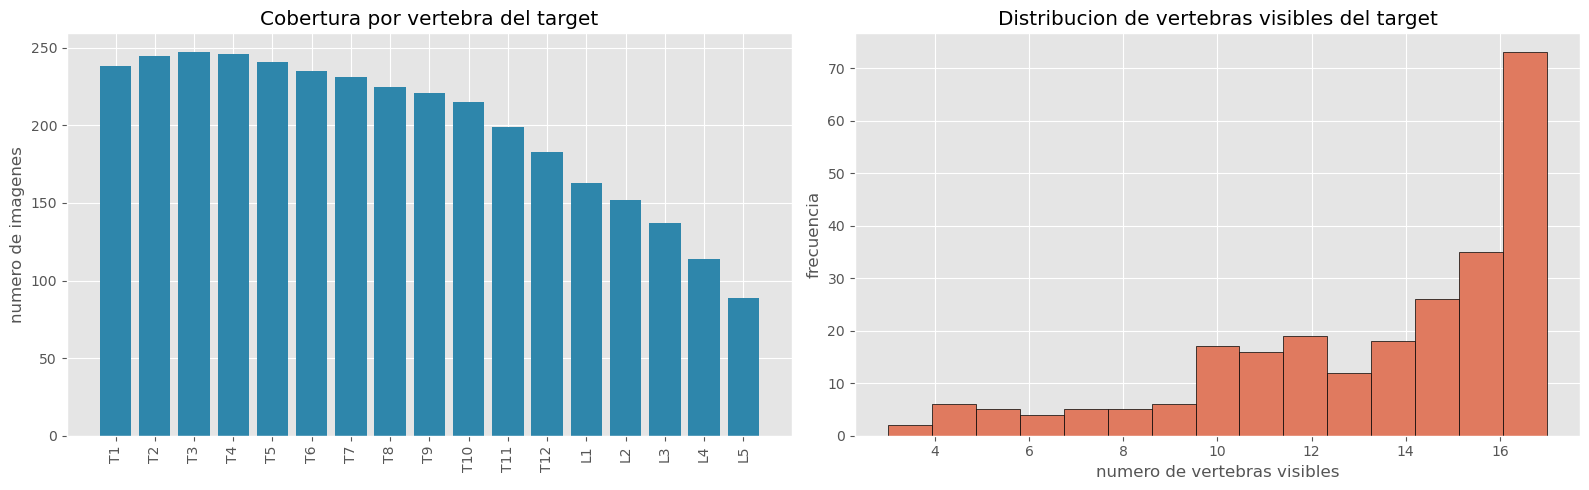

In [6]:
coverage_rows = []
for label in target_labels:
    count = int(presence_df[f'present_{label}'].sum())
    coverage_rows.append({'vertebra_label': label, 'region': 'thoracic' if label.startswith('T') else 'lumbar', 'image_count': count, 'coverage_rate': count / len(presence_df)})

vertebra_coverage_df = pd.DataFrame(coverage_rows)
display(vertebra_coverage_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(vertebra_coverage_df['vertebra_label'], vertebra_coverage_df['image_count'], color='#2E86AB')
axes[0].set_title('Cobertura por vertebra del target')
axes[0].tick_params(axis='x', rotation=90)
axes[0].set_ylabel('numero de imagenes')

axes[1].hist(coverage_df['num_visible_target_vertebrae'], bins=min(17, coverage_df['num_visible_target_vertebrae'].nunique()), color='#E07A5F', edgecolor='black')
axes[1].set_title('Distribucion de vertebras visibles del target')
axes[1].set_xlabel('numero de vertebras visibles')
axes[1].set_ylabel('frecuencia')

plt.tight_layout()


In [7]:
span_frequency_df = (
    coverage_df['visible_target_span_signature']
    .value_counts()
    .rename_axis('visible_target_span_signature')
    .reset_index(name='count')
)
display(span_frequency_df.head(20))

review_candidates_df = coverage_df.loc[
    (coverage_df['total_internal_missing_count'] > 0) | (coverage_df['unexpected_label_count'] > 0),
    [
        'split', 'image', 'present_target_vertebrae', 'present_excluded_cervical_labels',
        'thoracic_internal_missing_labels', 'lumbar_internal_missing_labels', 'unexpected_labels'
    ]
].copy()

print(f'Muestras sugeridas para revision manual: {len(review_candidates_df)}')
display(review_candidates_df.head(20))


,visible_target_span_signature,count
0,T1-L5,79
1,T1-L4,26
2,T1-L3,21
3,T1-T12,19
4,T1-T10,17
5,T1-L2,16
6,T1-T11,16
7,T1-L1,11
8,T2-L5,6
9,T1-T4,6


Muestras sugeridas para revision manual: 8


,split,image,present_target_vertebrae,present_excluded_cervical_labels,thoracic_internal_missing_labels,lumbar_internal_missing_labels,unexpected_labels
13,Normal,N_14.jpg,"T1, T2, T3, T4, T5, T6, T7, T9, T10, T11, T12,...",,T8,,
37,Normal,N_38.jpg,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",,,L4,
42,Normal,N_43.jpg,"T1, T2, T3, T4, T5, T6, T7, T9, T10, T11, T12,...",,T8,,
51,Normal,N_52.jpg,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T11, T12, ...",,T10,,
58,Normal,N_59.jpg,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",,,L2,
64,Normal,N_65.jpg,"T1, T2, T3, T4, T5, T6, T8, T9, T10, T11, T12,...",,T7,,
70,Normal,N_71.jpg,"T2, T3, T4, T5, T6, T7, T8, T10, T11, T12, L1,...",,T9,,
194,Scoliosis,S_150.jpg,"T1, T2, T3, T4, T5, T7, T8, T9, T10, T11, T12,...",,T6,,


## 2. Reglas practicas para entrenamiento thoracolumbar

Ahora definimos subsets utiles para el siguiente notebook de entrenamiento.

Se proponen tres usos:

- `binary_spine_all`: todas las muestras, para columna vs fondo.
- `thoracolumbar_core`: subset comun y estable del target thoracic + lumbar.
- `thoracolumbar_partial`: muestras parciales del target, pero sin huecos internos reales ni clases atipicas.

Para construir el `core`, usamos un umbral alto de frecuencia de cobertura. Aqui se deja parametrizable.


In [8]:
CORE_THRESHOLD = 0.80
MIN_VISIBLE_TARGET_VERTEBRAE = 6

core_labels = vertebra_coverage_df.loc[vertebra_coverage_df['coverage_rate'] >= CORE_THRESHOLD, 'vertebra_label'].tolist()
core_target_id_map = {label_to_id[label]: idx + 1 for idx, label in enumerate(core_labels)}

manifest_df = coverage_df.copy()
manifest_df['unique_sample_id'] = manifest_df['split'].astype(str) + '__' + manifest_df['image'].astype(str)
manifest_df['group_id_for_split'] = manifest_df['split'].astype(str) + '_' + manifest_df['patient_id'].astype(str)
manifest_df['target_class'] = manifest_df['split'].map({'Normal': 0, 'Scoliosis': 1})

for label in target_labels:
    manifest_df[f'present_{label}'] = presence_df[f'present_{label}']

manifest_df['all_core_labels_present'] = True
for label in core_labels:
    manifest_df['all_core_labels_present'] &= manifest_df[f'present_{label}'].eq(1)

manifest_df['usable_for_binary_spine'] = True
manifest_df['usable_for_thoracolumbar_core'] = (
    manifest_df['all_core_labels_present']
    & manifest_df['total_internal_missing_count'].eq(0)
    & manifest_df['unexpected_label_count'].eq(0)
)
manifest_df['usable_for_thoracolumbar_partial'] = (
    manifest_df['num_visible_target_vertebrae'].ge(MIN_VISIBLE_TARGET_VERTEBRAE)
    & manifest_df['total_internal_missing_count'].eq(0)
    & manifest_df['unexpected_label_count'].eq(0)
)
manifest_df['needs_annotation_review'] = (
    manifest_df['total_internal_missing_count'].gt(0)
    | manifest_df['unexpected_label_count'].gt(0)
)
manifest_df['usable_for_cobb_regression'] = manifest_df['split'].eq('Scoliosis')

for path_col in ['radiograph_path', 'mask_path']:
    manifest_df[f'{path_col}_abs'] = manifest_df[path_col].apply(lambda rel: str((DATASET_DIR / rel).resolve()))

display(pd.DataFrame({'core_labels': core_labels}))
display(pd.DataFrame({'core_target_id_old_to_new': [core_target_id_map]}))
display(pd.DataFrame([
    {'bucket': 'binary_spine_all', 'images': int(manifest_df['usable_for_binary_spine'].sum())},
    {'bucket': 'thoracolumbar_core', 'images': int(manifest_df['usable_for_thoracolumbar_core'].sum())},
    {'bucket': 'thoracolumbar_partial', 'images': int(manifest_df['usable_for_thoracolumbar_partial'].sum())},
    {'bucket': 'needs_annotation_review', 'images': int(manifest_df['needs_annotation_review'].sum())},
    {'bucket': 'usable_for_cobb_regression', 'images': int(manifest_df['usable_for_cobb_regression'].sum())},
]))


,core_labels
0,T1
1,T2
2,T3
3,T4
4,T5
5,T6
6,T7
7,T8
8,T9
9,T10


,core_target_id_old_to_new
0,"{1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: ..."


,bucket,images
0,binary_spine_all,249
1,thoracolumbar_core,198
2,thoracolumbar_partial,228
3,needs_annotation_review,8
4,usable_for_cobb_regression,178


In [9]:
manifest_columns = [
    'unique_sample_id', 'group_id_for_split', 'split', 'image', 'patient_id', 'target_class',
    'radiograph_path', 'radiograph_path_abs', 'mask_path', 'mask_path_abs',
    'num_visible_target_vertebrae', 'first_visible_target', 'last_visible_target', 'visible_target_span_signature',
    'excluded_cervical_count', 'present_excluded_cervical_labels',
    'thoracic_count', 'lumbar_count',
    'thoracic_internal_missing_count', 'lumbar_internal_missing_count', 'total_internal_missing_count',
    'thoracic_internal_missing_labels', 'lumbar_internal_missing_labels',
    'unexpected_label_count', 'unexpected_labels',
    'usable_for_binary_spine', 'usable_for_thoracolumbar_core', 'usable_for_thoracolumbar_partial', 'needs_annotation_review', 'usable_for_cobb_regression'
]

display(manifest_df[manifest_columns].head(20))


,unique_sample_id,group_id_for_split,split,image,patient_id,target_class,radiograph_path,radiograph_path_abs,mask_path,mask_path_abs,num_visible_target_vertebrae,first_visible_target,last_visible_target,visible_target_span_signature,excluded_cervical_count,present_excluded_cervical_labels,thoracic_count,lumbar_count,thoracic_internal_missing_count,lumbar_internal_missing_count,total_internal_missing_count,thoracic_internal_missing_labels,lumbar_internal_missing_labels,unexpected_label_count,unexpected_labels,usable_for_binary_spine,usable_for_thoracolumbar_core,usable_for_thoracolumbar_partial,needs_annotation_review,usable_for_cobb_regression
0,Normal__N_1.jpg,Normal_1,Normal,N_1.jpg,1,0,Normal/N_1.jpg,C:\Users\JOHN\MAIA-PROYECTO\Scoliosis_Dataset_...,LabelMultiClass_ID_PNG/LabelMulti_N_1.png,C:\Users\JOHN\MAIA-PROYECTO\Scoliosis_Dataset_...,17,T1,L5,T1-L5,0,,12,5,0,0,0,,,0,,True,True,True,False,False
1,Normal__N_2.jpg,Normal_2,Normal,N_2.jpg,2,0,Normal/N_2.jpg,C:\Users\JOHN\MAIA-PROYECTO\Scoliosis_Dataset_...,LabelMultiClass_ID_PNG/LabelMulti_N_2.png,C:\Users\JOHN\MAIA-PROYECTO\Scoliosis_Dataset_...,17,T1,L5,T1-L5,0,,12,5,0,0,0,,,0,,True,True,True,False,False
2,Normal__N_3.jpg,Normal_3,Normal,N_3.jpg,3,0,Normal/N_3.jpg,C:\Users\JOHN\MAIA-PROYECTO\Scoliosis_Dataset_...,LabelMultiClass_ID_PNG/LabelMulti_N_3.png,C:\Users\JOHN\MAIA-PROYECTO\Scoliosis_Dataset_...,17,T1,L5,T1-L5,0,,12,5,0,0,0,,,0,,True,True,True,False,False
3,Normal__N_4.jpg,Normal_4,Normal,N_4.jpg,4,0,Normal/N_4.jpg,C:\Users\JOHN\MAIA-PROYECTO\Scoliosis_Dataset_...,LabelMultiClass_ID_PNG/LabelMulti_N_4.png,C:\Users\JOHN\MAIA-PROYECTO\Scoliosis_Dataset_...,17,T1,L5,T1-L5,0,,12,5,0,0,0,,,0,,True,True,True,False,False
4,Normal__N_5.jpg,Normal_5,Normal,N_5.jpg,5,0,Normal/N_5.jpg,C:\Users\JOHN\MAIA-PROYECTO\Scoliosis_Dataset_...,LabelMultiClass_ID_PNG/LabelMulti_N_5.png,C:\Users\JOHN\MAIA-PROYECTO\Scoliosis_Dataset_...,17,T1,L5,T1-L5,0,,12,5,0,0,0,,,0,,True,True,True,False,False
5,Normal__N_6.jpg,Normal_6,Normal,N_6.jpg,6,0,Normal/N_6.jpg,C:\Users\JOHN\MAIA-PROYECTO\Scoliosis_Dataset_...,LabelMultiClass_ID_PNG/LabelMulti_N_6.png,C:\Users\JOHN\MAIA-PROYECTO\Scoliosis_Dataset_...,17,T1,L5,T1-L5,0,,12,5,0,0,0,,,0,,True,True,True,False,False
6,Normal__N_7.jpg,Normal_7,Normal,N_7.jpg,7,0,Normal/N_7.jpg,C:\Users\JOHN\MAIA-PROYECTO\Scoliosis_Dataset_...,LabelMultiClass_ID_PNG/LabelMulti_N_7.png,C:\Users\JOHN\MAIA-PROYECTO\Scoliosis_Dataset_...,17,T1,L5,T1-L5,0,,12,5,0,0,0,,,0,,True,True,True,False,False
7,Normal__N_8.jpg,Normal_8,Normal,N_8.jpg,8,0,Normal/N_8.jpg,C:\Users\JOHN\MAIA-PROYECTO\Scoliosis_Dataset_...,LabelMultiClass_ID_PNG/LabelMulti_N_8.png,C:\Users\JOHN\MAIA-PROYECTO\Scoliosis_Dataset_...,17,T1,L5,T1-L5,0,,12,5,0,0,0,,,0,,True,True,True,False,False
8,Normal__N_9.jpg,Normal_9,Normal,N_9.jpg,9,0,Normal/N_9.jpg,C:\Users\JOHN\MAIA-PROYECTO\Scoliosis_Dataset_...,LabelMultiClass_ID_PNG/LabelMulti_N_9.png,C:\Users\JOHN\MAIA-PROYECTO\Scoliosis_Dataset_...,17,T1,L5,T1-L5,0,,12,5,0,0,0,,,0,,True,True,True,False,False
9,Normal__N_10.jpg,Normal_10,Normal,N_10.jpg,10,0,Normal/N_10.jpg,C:\Users\JOHN\MAIA-PROYECTO\Scoliosis_Dataset_...,LabelMultiClass_ID_PNG/LabelMulti_N_10.png,C:\Users\JOHN\MAIA-PROYECTO\Scoliosis_Dataset_...,17,T1,L5,T1-L5,0,,12,5,0,0,0,,,0,,True,True,True,False,False


## 3. Ejemplos visuales

Mostramos una muestra amplia del target y una muestra parcial aceptable. En ambas, las cervicales pueden existir en la imagen, pero no forman parte del objetivo de entrenamiento.


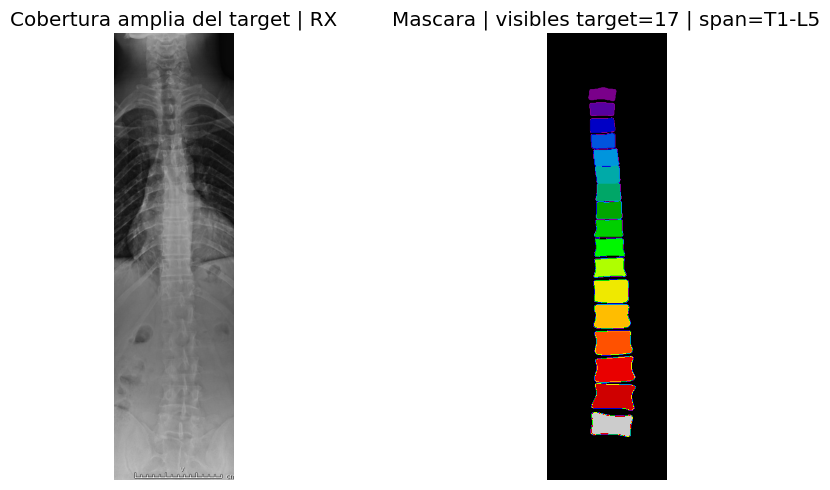

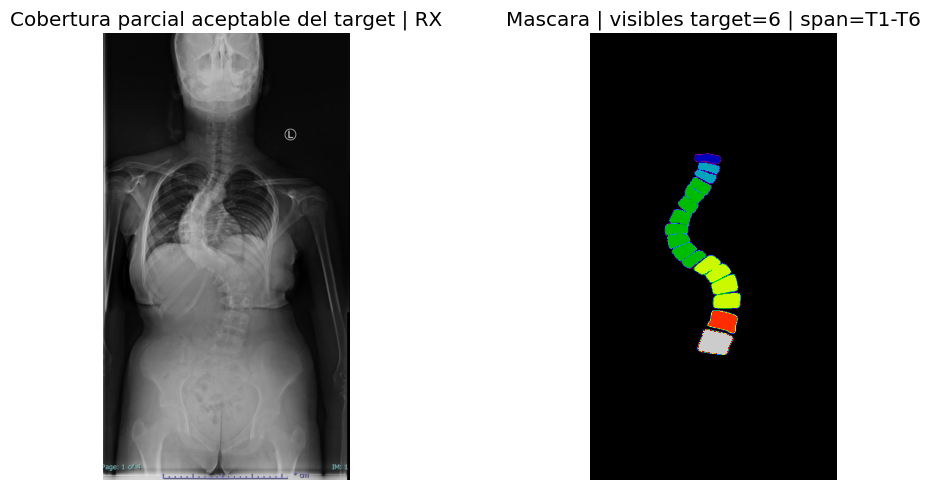

In [10]:
def show_sample(sample_row: pd.Series, title: str):
    image = np.array(Image.open(DATASET_DIR / sample_row['radiograph_path']))
    mask = np.array(Image.open(DATASET_DIR / sample_row['mask_path']))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(image, cmap='gray' if image.ndim == 2 else None)
    axes[0].set_title(f'{title} | RX')
    axes[0].axis('off')

    axes[1].imshow(mask, cmap='nipy_spectral')
    axes[1].set_title(f"Mascara | visibles target={sample_row['num_visible_target_vertebrae']} | span={sample_row['visible_target_span_signature']}")
    axes[1].axis('off')
    plt.tight_layout()


wide_sample = manifest_df.sort_values('num_visible_target_vertebrae', ascending=False).iloc[0]
partial_sample = manifest_df.loc[manifest_df['usable_for_thoracolumbar_partial']].sort_values('num_visible_target_vertebrae', ascending=True).iloc[0]

show_sample(wide_sample, title='Cobertura amplia del target')
show_sample(partial_sample, title='Cobertura parcial aceptable del target')


## 4. Exportacion de artefactos

Este notebook exporta artefactos utiles para el siguiente notebook de entrenamiento:
- `thoracolumbar_coverage_summary_V3.csv`
- `thoracolumbar_presence_matrix_V3.csv`
- `training_manifest_thoracolumbar_v3.csv`


In [11]:
coverage_summary_path = OUTPUT_DIR / 'thoracolumbar_coverage_summary_V3.csv'
presence_matrix_path = OUTPUT_DIR / 'thoracolumbar_presence_matrix_V3.csv'
manifest_path = OUTPUT_DIR / 'training_manifest_thoracolumbar_v3.csv'

coverage_df.to_csv(coverage_summary_path, index=False)
presence_df.to_csv(presence_matrix_path, index=False)
manifest_df[manifest_columns].to_csv(manifest_path, index=False)

print('Archivos exportados:')
print('-', coverage_summary_path)
print('-', presence_matrix_path)
print('-', manifest_path)


Archivos exportados:
- C:\Users\JOHN\MAIA-PROYECTO\analysis_outputs_v3\thoracolumbar_coverage_summary_V3.csv
- C:\Users\JOHN\MAIA-PROYECTO\analysis_outputs_v3\thoracolumbar_presence_matrix_V3.csv
- C:\Users\JOHN\MAIA-PROYECTO\analysis_outputs_v3\training_manifest_thoracolumbar_v3.csv


## 5. Conclusiones operativas para el siguiente notebook de entrenamiento

Despues de este analisis, la idea para entrenar sera:

- usar `usable_for_binary_spine = True` para segmentacion binaria,
- usar `usable_for_thoracolumbar_core = True` para arrancar una multiclase estable,
- y luego ampliar a `usable_for_thoracolumbar_partial = True` si quieres entrenar con cobertura parcial del target.

Punto importante: las cervicales ya no son parte del problema de modelado. Si aparecen en la mascara, se deben tratar como anatomia visible pero **fuera del target**, no como fallo de anotacion.


 ### Analisis e Interpretacion
 
este notebook ya quedó lo bastante sólido para continuar a la siguiente etapa. Revisando thoracolumbar_coverage_strategy_V3.ipynb y sus salidas, la lógica está bien alineada con la decisión nueva del proyecto: trabajar solo con thoracic + lumbar (T1-T12, L1-L5). Además, el manifiesto resultante ya separa correctamente los grupos para entrenamiento en training_manifest_thoracolumbar_v3.csv.

Lo más importante que veo en resultados:

250 imágenes totales.
249 tienen al menos una vértebra objetivo visible.
250 sirven para segmentación binaria de columna.
198 sirven para multiclase thoracolumbar core.
228 sirven para multiclase thoracolumbar partial.
Solo 8 quedaron marcadas para revisión manual.
Solo 8 tienen faltantes internos y 7 etiquetas inesperadas.
Eso, en práctica, significa que no tienes un bloqueo de calidad para seguir. El notebook cumple su objetivo de auditoría y deja una base clara para entrenar.

Lo que todavía debes tener presente, pero ya no impide avanzar:

La cobertura lumbar cae bastante al final: L4=114 y L5=89, así que esas clases estarán más débiles.
El set core está desbalanceado hacia Scoliosis (134) frente a Normal (60).
Los 12 casos en revisión conviene dejarlos fuera del multiclase inicial.
Mi recomendación concreta es esta:

Sí, pasemos a la otra etapa.
Entrena primero segmentación binaria con las 250.
Luego entrena multiclase thoracolumbar usando primero el subconjunto thoracolumbar_core = 194.
Deja thoracolumbar_partial = 224 para una segunda iteración, cuando ya tengamos una línea base estable.

## 6. Resumen de hallazgos, conclusiones e interpretación (V3)

### Resumen de hallazgos

- Se auditó un total de **250 estudios** en `Scoliosis_Dataset_V3/Scoliosis_Dataset` (71 `Normal` y 179 `Scoliosis`), usando como target solo **T1-T12 y L1-L5**.
- La calidad semántica de etiquetas para el objetivo thoracolumbar es consistente: **0 casos con etiquetas inesperadas** (`unexpected_label_count = 0`).
- Cobertura para binario (`columna vs fondo`): **250/250** muestras utilizables (`usable_for_binary_spine = True`).
- Cobertura para multiclase thoracolumbar:
  - Subconjunto **core**: **198/250** muestras (`usable_for_thoracolumbar_core = True`).
  - Subconjunto **partial**: **228/250** muestras (`usable_for_thoracolumbar_partial = True`).
- Se identificaron **8 casos** con faltantes internos (`total_internal_missing_count > 0`), marcados para revisión (`needs_annotation_review = True`).
- Distribución de visibilidad:
  - **73** muestras con cobertura completa de 17 vértebras target.
  - **1** muestra sin vértebras target visibles (`num_visible_target_vertebrae = 0`).
  - **86** muestras sin cobertura lumbar (`lumbar_count = 0`), lo que confirma variabilidad de campo de visión entre estudios.

### Conclusiones

1. El conjunto bajo `Scoliosis_Dataset_V3/Scoliosis_Dataset` es **apto para iniciar entrenamiento binario** de forma inmediata, porque toda muestra contiene información útil para delimitar columna frente a fondo.
2. El dataset también es **apto para entrenamiento multiclase**, especialmente con una estrategia por niveles:
   - usar primero el subset **core** para una etapa inicial más estable,
   - y luego incorporar **partial** para ampliar variabilidad y robustez.
3. La baja cantidad de casos con inconsistencias internas (8/250) sugiere que la preparación de datos es suficientemente sólida para avanzar, manteniendo trazabilidad de casos a revisar.
4. La heterogeneidad anatómica observada (incluyendo estudios sin región lumbar visible) no es un problema del pipeline: es una propiedad real del dataset que debe modelarse explícitamente con reglas de entrenamiento y evaluación.

### Análisis e interpretación de resultados

Los resultados muestran que el cuello de botella principal **no está en la calidad de etiquetas** (no hay clases fuera del diccionario objetivo), sino en la **variabilidad de cobertura anatómica por imagen**. Esto impacta más al modelo multiclase que al binario: el binario solo necesita distinguir estructura espinal global, mientras que el multiclase debe asignar identidad vertebral fina bajo distintos niveles de truncamiento (por ejemplo, estudios torácicos sin lumbar o coberturas incompletas). Por eso la separación en `core` y `partial` es técnicamente correcta: permite arrancar con un régimen de menor ambigüedad para aprender correspondencias vertebrales más estables y, en una segunda fase, exponer al modelo a mayor diversidad sin perder control sobre la calidad del entrenamiento.

Además, el hecho de que exista una fracción relevante sin lumbar visible (86 casos) anticipa que métricas agregadas deben interpretarse por subgrupos (cobertura completa vs parcial) para evitar conclusiones engañosas. Esta lectura respalda que el manifiesto exportado en V3 no sea solo un archivo de entrada, sino una capa de control de calidad y gobernanza del entrenamiento.

**Justificación para pasar a las siguientes etapas (binaria y multiclase):** Dado que `thoracolumbar_coverage_strategy_v3` confirma integridad de etiquetas (0 inesperadas), disponibilidad total para segmentación binaria (250/250), y un volumen suficiente para aprendizaje multiclase en modo controlado (198 core y 228 partial), es metodológicamente consistente avanzar a `train_spine_binary_and_thoracolumbar_v3` y luego a `train_spine_cascade_binary_to_thoracolumbar_v3`. Primero, la segmentación binaria establece una localización robusta de la columna y reduce el efecto del fondo dominante; segundo, el entrenamiento multiclase aprovecha esa localización para aprender identificación vertebral con mejor relación señal/ruido. En consecuencia, ambos notebooks V3 son una continuación directa y sustentada por los hallazgos de esta auditoría, no una decisión ad hoc.

## 7. Resumen de hallazgos, conclusiones e interpretación (tras corrida completa V3)

### Resumen de hallazgos

- Se auditó el índice exportado por esta corrida sobre **`Scoliosis_Dataset_V3/Scoliosis_Dataset`**, con **249 estudios** en total (**71** `Normal` y **178** `Scoliosis`).
- Integridad semántica del diccionario multiclase (T1–T12, L1–L5): **0 imágenes con etiquetas inesperadas** (`unexpected_label_count = 0` en todas las filas del manifiesto).
- **Segmentación binaria (columna vs fondo):** **249/249** casos marcados como utilizables (`usable_for_binary_spine = True`).
- **Segmentación multiclase thoracolumbar:**
  - Subconjunto **core** (entrenamiento más estricto): **198/249** (`usable_for_thoracolumbar_core = True`).
  - Subconjunto **partial** (mayor cobertura anatómica permitida): **228/249** (`usable_for_thoracolumbar_partial = True`).
- **Control de calidad:** **8 casos** con al menos un faltante interno entre vértebras target (`total_internal_missing_count > 0`), marcados para revisión (`needs_annotation_review = True`).
- **Cobertura lumbar:** **164** estudios con al menos una vértebra lumbar visible; **85** sin región lumbar en la máscara (campo de visión parcial o truncamiento anatómico).
- **Cobertura “completa” del target:** **73** estudios con las **17** vértebras target visibles a la vez; el número de vértebras visibles promedio es **~13,6** (mediana **15**), reflejando variabilidad real de encuadre.
- **Casos sin vértebras target visibles:** **0** en esta corrida (`num_visible_target_vertebrae = 0` para ninguna fila), lo que indica que el índice V3 usado aquí no incluye máscaras vacías de contenido útil para el target.

### Conclusiones

1. El pipeline de auditoría y el **manifiesto `training_manifest_thoracolumbar_v3.csv`** quedan como **contrato de datos** entre este notebook y los de entrenamiento: rutas verificadas, flags de uso y señales de revisión explícitas.
2. La base es **adecuada para entrenar primero un modelo binario** en todas las muestras disponibles, porque no hay exclusiones por integridad de etiquetas inesperadas y el binario no exige las 17 clases simultáneas.
3. El entrenamiento **multiclase** debe plantearse en **dos niveles** coherente con los flags: **core** para una primera línea base estable y **partial** para ampliar robustez ante anatomías parcialmente visibles.
4. La fracción de estudios **sin lumbar** (**85**) no es un “error” del código: es una característica del conjunto que obliga a interpretar métricas por subgrupos (p. ej. con/sin lumbar) y a no confundir *accuracy* global con calidad clínica por región.

### Análisis e interpretación de los resultados

Los resultados confirman que el cuello de botella principal no es la **validez nominal de las clases** (cero etiquetas fuera del esquema T1–L5), sino la **heterogeneidad de visibilidad anatómica** entre radiografías. Eso explica la brecha entre **249** muestras aptas para binario y **198** aptas para *core* multiclase: el multiclase exige simultáneamente más estructura vertebral “útil” y continuidad interna dentro de torácico y lumbar, mientras el binario solo necesita separar columna frente a fondo. Los **8** casos con huecos internos son pocos en relación al total, pero su existencia justifica mantener un canal de **revisión anotada** antes de usar esos ejemplos como referencia “dorada” en etapas avanzadas.

En conjunto, la distribución por `split` (**71/178**) y los conteos por modo de entrenamiento soportan un plan experimental: **binario primero** para anclar la localización espinal; **multiclase después**, primero en *core* y luego ampliando a *partial*, alineado con lo que consumen `train_spine_binary_and_thoracolumbar_v3.ipynb` y `train_spine_cascade_binary_to_thoracolumbar_v3.ipynb` a partir de este manifiesto.

**Justificación para pasar a las siguientes etapas (segmentación binaria y entrenamiento multiclase):** Con un manifiesto ya depurado y **0 etiquetas inesperadas**, tiene sentido avanzar sin bloqueos de consistencia de esquema. La **segmentación binaria** reduce el dominio visual a la anatomía relevante y mitiga el sesgo de métricas dominadas por fondo en radiografías amplias; sobre esa base, el **entrenamiento multiclase** aborda el objetivo científico real (identidad vertebral T1–L5). Los dos notebooks de entrenamiento en **V3** están diseñados para consumir **exactamente** las decisiones de este análisis (`usable_for_*`, revisiones, rutas); por tanto, continuar con ellos no es un paso arbitrario, sino la ejecución del plan de datos que aquí se validó.
